In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn import linear_model
from sklearn import model_selection
# from sklearn import metrics
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    r2_score,
    classification_report
)
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import KeyedVectors
# from gensim.models.fasttext import load_facebook_model
import gensim.downloader as api
import re
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm



TEST_SIZE = 0.2
RANDOM_SEED = 42

In [2]:
df = pd.read_csv("../data/toxic_comments_with_morph.csv")
df.drop(columns=["Unnamed: 0", "swearing.1"], inplace=True)
df_categorical = df.drop(columns=['comment', 'cleaned_comment', 'comment_without_punct'])

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(df[['label']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['label']))
df_categorical = pd.concat([df.drop(columns=['label']), encoded_df], axis=1)
df_categorical = df_categorical.drop(columns=['label_NORMAL', 'comment', 'cleaned_comment', 'comment_without_punct'])
df_binary = df_categorical.drop(columns=['label_INSULT', 'label_OBSCENITY', 'label_THREAT'])

In [3]:
def print_binary_metrics(y_test, y_pred):
    # Вычисление метрик
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_pred)  # или y_pred_proba, если хотите AUC по вероятностям
    r2 = r2_score(y_test, y_pred)

    # Матрица ошибок
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Красивый вывод
    print("=" * 50)
    print("📊 РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ")
    print("=" * 50)
    print(f"{'Accuracy:':<25} {accuracy:.4f}")
    print(f"{'Precision:':<25} {precision:.4f}")
    print(f"{'Recall:':<25} {recall:.4f}")
    print(f"{'F1-Score (F-macro):':<25} {f1:.4f}")
    print(f"{'AUC-ROC:':<25} {auc:.4f}")
    print(f"{"R2: ": <25} {r2:.4f}")
    print("-" * 50)
    print("🧩 Матрица ошибок:")
    print(f"{'':<8} {'Предсказано: 0':<15} {'Предсказано: 1':<15}")
    print(f"{'Факт: 0':<8} {tn:<15} {fp:<15}")
    print(f"{'Факт: 1':<8} {fn:<15} {tp:<15}")
    print("-" * 50)

    # # Дополнительно: подробный отчёт (если нужно)
    # print("📋 Подробный классификационный отчёт:")
    # print(classification_report(y_test, y_pred, target_names=['Класс 0', 'Класс 1']))


In [4]:
X = df_binary.drop(columns=['is_normal'])
y = df_binary['is_normal']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)

In [5]:
lr = linear_model.LogisticRegression(max_iter=50000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print_binary_metrics(y_test, y_pred)

📊 РЕЗУЛЬТАТЫ БИНАРНОЙ КЛАССИФИКАЦИИ
Accuracy:                 0.9007
Precision:                0.8943
Recall:                   0.9968
F1-Score (F-macro):       0.7844
AUC-ROC:                  0.7295
R2:                       0.3265
--------------------------------------------------
🧩 Матрица ошибок:
         Предсказано: 0  Предсказано: 1 
Факт: 0  4124            4797           
Факт: 1  132             40604          
--------------------------------------------------


##

<h2>Мультиклассовая классификация (без word2vec)

#

In [6]:
df_multiclass = df_binary.drop(columns=['is_normal'])
df_multiclass['label'] = df['label']
df_multiclass['text'] = df['comment']
X = df_multiclass.drop(columns=['label'])
y = df_multiclass['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)

X_train_text = X_train['text']
X_train.drop(columns='text', inplace=True)
X_test_text = X_test['text']
X_test.drop(columns='text', inplace=True)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [7]:
def print_multiclass_metrics(y_test, y_pred, model_name='LR'):
    print("f1 macro score:", f1_score(y_test, y_pred, average='macro'))
    print("f1 weighted score:", f1_score(y_test, y_pred, average='weighted'))
    print(f"{model_name} accurcay:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['INSULT', 'NORMAL', 'THREAT', 'OBSCENITY']))


    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=df['label'].unique(), yticklabels=df['label'].unique())

<h3> LogisticRegression

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


f1 macro score: 0.3940950087827806
f1 weighted score: 0.8445724650324956
LR accurcay: 0.8793926334655738
              precision    recall  f1-score   support

      INSULT       0.75      0.54      0.63      5713
      NORMAL       0.89      1.00      0.94     40736
      THREAT       0.08      0.00      0.00       852
   OBSCENITY       0.05      0.00      0.00      2356

    accuracy                           0.88     49657
   macro avg       0.44      0.39      0.39     49657
weighted avg       0.82      0.88      0.84     49657



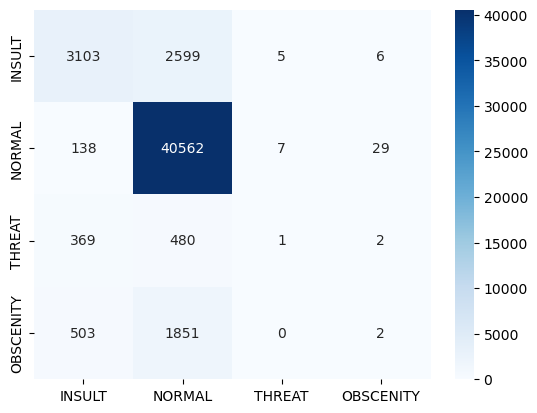

In [8]:
# # Обычная LogisticRegression без гиперпараметров

lr = linear_model.LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print_multiclass_metrics(y_test, y_pred)

In [9]:
# добавим нормализацию признаков

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

f1 macro score: 0.3964151749121985
f1 weighted score: 0.8469841797612057
LR accurcay: 0.8820710071087662
              precision    recall  f1-score   support

      INSULT       0.77      0.55      0.64      5713
      NORMAL       0.89      1.00      0.94     40736
      THREAT       0.00      0.00      0.00       852
   OBSCENITY       0.14      0.00      0.00      2356

    accuracy                           0.88     49657
   macro avg       0.45      0.39      0.40     49657
weighted avg       0.83      0.88      0.85     49657



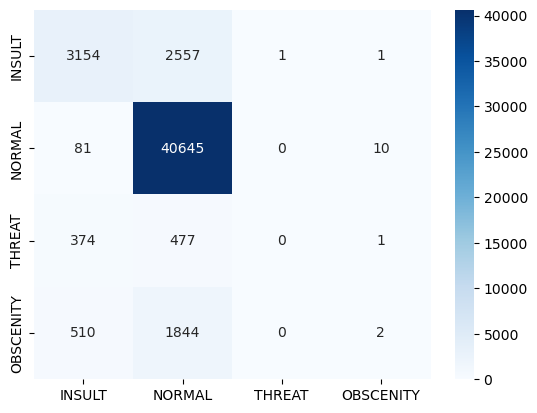

In [10]:
# Обычная LogisticRegression с нормализацией признаков
lr = linear_model.LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print_multiclass_metrics(y_test, y_pred)

In [ ]:
# сделаем подбор гиперпараметров
lr = linear_model.LogisticRegression(max_iter=1000, n_jobs=-1, solver='saga', penalty='l2')

param_grid = {
    "penalty": ["l2"],
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["saga"], 
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

f1 macro score: 0.39645295549964554
f1 weighted score: 0.8470101655407497
LR accurcay: 0.8821112834041525
              precision    recall  f1-score   support

      INSULT       0.77      0.55      0.64      5713
      NORMAL       0.89      1.00      0.94     40736
      THREAT       0.00      0.00      0.00       852
   OBSCENITY       0.15      0.00      0.00      2356

    accuracy                           0.88     49657
   macro avg       0.45      0.39      0.40     49657
weighted avg       0.83      0.88      0.85     49657



/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

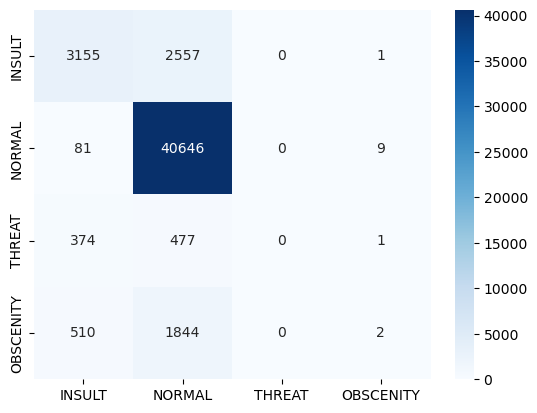

In [ ]:
y_pred = grid.predict(X_test)
print_multiclass_metrics(y_test, y_pred)

<h3> Feature Engineering

In [13]:
# доля уникальных слов
df_multiclass['unique_fraction'] = df_multiclass['text'].apply(lambda x: len(set(x.split())) / len(x.split()))

# количество цифр в комментарии
df_multiclass['num_digits'] = df_multiclass['text'].apply(lambda x: len(re.findall(r'[0-9]', x)))

# доля некириллических букв в комментарии (знаки препинания, смайлы, латиница, итд)
df_multiclass['non_cyrillic'] = df_multiclass['text'].apply(lambda x: len(re.findall(r'[^а-яА-ЯËё0-9 ]', x)) / len(x))

# наличие ссылки в комментарии
LINKS = ['www', '.com', '.ru', 'http:']
links_regex = re.compile(r"\b(" + "|".join(LINKS) + r")\b", re.IGNORECASE)
df_multiclass['has_link'] = df_multiclass['text'].apply(lambda x: bool(links_regex.search(x)))


X = df_multiclass.drop(columns=['label'])
y = df_multiclass['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)

X_train.drop(columns='text', inplace=True)
X_test.drop(columns='text', inplace=True)

# разделим X на новые + старые и старые признаки
X_train_new = X_train.copy()
X_test_new = X_test.copy()
X_train = X_train.drop(columns=['unique_fraction', 'num_digits', 'non_cyrillic', 'has_link']).copy()
X_test = X_test.drop(columns=['unique_fraction', 'num_digits', 'non_cyrillic', 'has_link']).copy()


In [14]:
# # # добавим еще числовых признаков на основе содержания комментария

# # доля уникальных слов
# X_train['unique_fraction'] = X_train_text.apply(lambda x: len(set(x.split())) / len(x.split()))
# X_test['unique_fraction'] = X_test_text.apply(lambda x: len(set(x.split())) / len(x.split()))

# # количество цифр в комментарии
# X_train['num_digits'] = X_train_text.apply(lambda x: len(re.findall(r'[0-9]', x)))
# X_test['num_digits'] = X_test_text.apply(lambda x: len(re.findall(r'[0-9]', x)))

# # доля некириллических букв в комментарии (знаки препинания, смайлы, латиница, итд)
# X_train['non_cyrillic'] = X_train_text.apply(lambda x: len(re.findall(r'[^а-яА-ЯËё0-9 ]', x)) / len(x))
# X_test['non_cyrillic'] = X_test_text.apply(lambda x: len(re.findall(r'[^а-яА-ЯËё0-9 ]', x)) / len(x))

# # наличие ссылки в комментарии
# LINKS = ['www', '.com', '.ru', 'http:']
# links_regex = re.compile(r"\b(" + "|".join(LINKS) + r")\b", re.IGNORECASE)
# X_train['has_link'] = X_train_text.apply(lambda x: bool(links_regex.search(x)))
# X_test['has_link'] = X_test_text.apply(lambda x: bool(links_regex.search(x)))

# # # разделим X на новые + старые и старые признаки
# # X_train_new = X_train.copy()
# # X_test_new = X_test.copy()
# # X_train = X_train[:13]
# # X_train = X_train[:13]

In [15]:
# добавим нормализацию для новых признаков
scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scaler = preprocessing.StandardScaler()
X_train_new = scaler.fit_transform(X_train_new)
X_test_new = scaler.transform(X_test_new)

f1 macro score: 0.3964151749121985
f1 weighted score: 0.8469841797612057
LR accurcay: 0.8820710071087662
              precision    recall  f1-score   support

      INSULT       0.77      0.55      0.64      5713
      NORMAL       0.89      1.00      0.94     40736
      THREAT       0.00      0.00      0.00       852
   OBSCENITY       0.14      0.00      0.00      2356

    accuracy                           0.88     49657
   macro avg       0.45      0.39      0.40     49657
weighted avg       0.83      0.88      0.85     49657



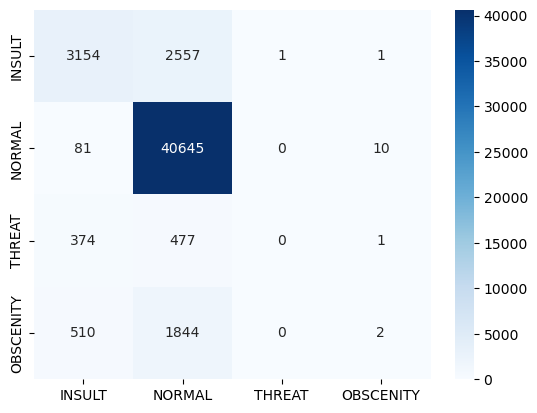

In [16]:
# # LogisticRegression с новыми признаками
lr = linear_model.LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print_multiclass_metrics(y_test, y_pred)

f1 macro score: 0.3967233538245219
f1 weighted score: 0.8470701835454352
LR accurcay: 0.8821112834041525
              precision    recall  f1-score   support

      INSULT       0.77      0.55      0.64      5713
      NORMAL       0.89      1.00      0.94     40736
      THREAT       0.00      0.00      0.00       852
   OBSCENITY       0.17      0.00      0.00      2356

    accuracy                           0.88     49657
   macro avg       0.46      0.39      0.40     49657
weighted avg       0.83      0.88      0.85     49657



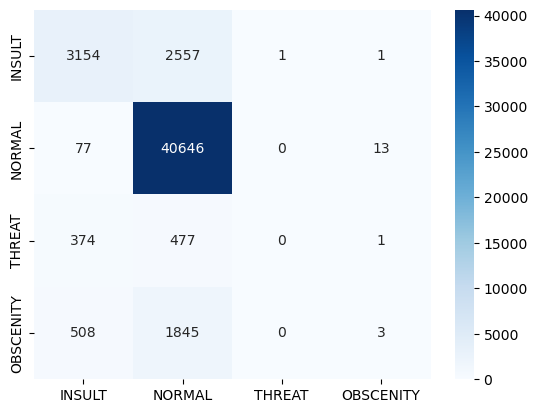

In [17]:
# LogisticRegression с новыми признаками
lr = linear_model.LogisticRegression()
lr.fit(X_train_new, y_train)
y_pred = lr.predict(X_test_new)

print_multiclass_metrics(y_test, y_pred)

In [18]:
# новые признаки дают небольшой прирост к метрике, добавим их к датасету

<h3> KNN

f1 macro score: 0.40207343038404864
f1 weighted score: 0.8410620778674708
LR accurcay: 0.8718005517852468
              precision    recall  f1-score   support

      INSULT       0.70      0.53      0.60      5713
      NORMAL       0.89      0.99      0.94     40736
      THREAT       0.16      0.02      0.04       852
   OBSCENITY       0.17      0.02      0.03      2356

    accuracy                           0.87     49657
   macro avg       0.48      0.39      0.40     49657
weighted avg       0.82      0.87      0.84     49657



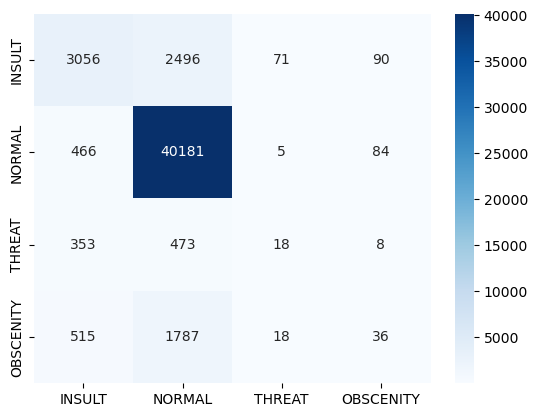

In [19]:
# обычный KNN без новых признаков
new_features = ['unique_fraction', 'num_digits', 'non_cyrillic', 'has_link']
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print_multiclass_metrics(y_test, y_pred_knn)

f1 macro score: 0.40306906331279313
f1 weighted score: 0.8415864208051042
LR accurcay: 0.8724651106591216
              precision    recall  f1-score   support

      INSULT       0.70      0.54      0.61      5713
      NORMAL       0.89      0.99      0.94     40736
      THREAT       0.22      0.02      0.04       852
   OBSCENITY       0.16      0.01      0.03      2356

    accuracy                           0.87     49657
   macro avg       0.49      0.39      0.40     49657
weighted avg       0.83      0.87      0.84     49657



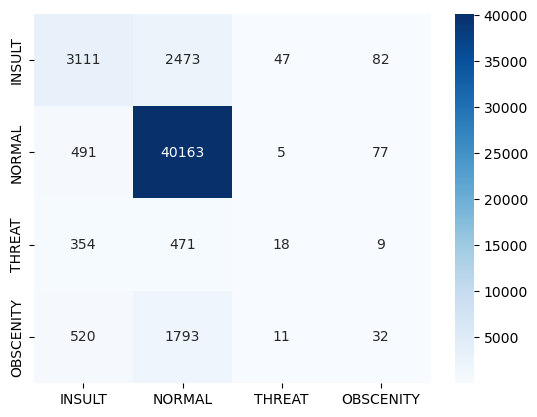

In [20]:
# обычный KNN с новыми признаками
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_new, y_train)
y_pred_knn = knn.predict(X_test_new)
print_multiclass_metrics(y_test, y_pred_knn)

<h3> Random Forest

f1 macro score: 0.40760932658597887
f1 weighted score: 0.8398080978332327
LR accurcay: 0.8677125078035323
              precision    recall  f1-score   support

      INSULT       0.70      0.52      0.60      5713
      NORMAL       0.89      0.98      0.94     40736
      THREAT       0.15      0.03      0.05       852
   OBSCENITY       0.13      0.03      0.04      2356

    accuracy                           0.87     49657
   macro avg       0.47      0.39      0.41     49657
weighted avg       0.82      0.87      0.84     49657



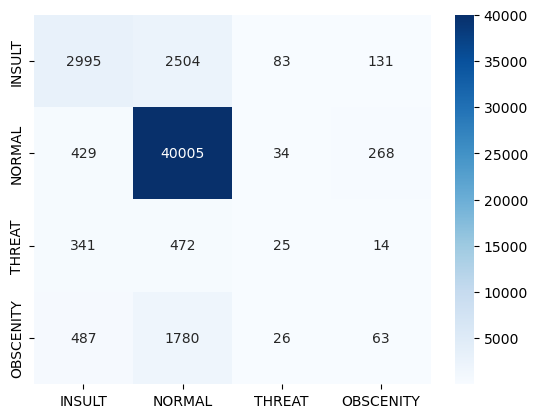

In [21]:
# обычный RF на старых признаках
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print_multiclass_metrics(y_test, y_pred_rf)

f1 macro score: 0.40709807313316043
f1 weighted score: 0.8423980903257215
LR accurcay: 0.8721026240006444
              precision    recall  f1-score   support

      INSULT       0.73      0.53      0.62      5713
      NORMAL       0.89      0.99      0.94     40736
      THREAT       0.17      0.02      0.04       852
   OBSCENITY       0.13      0.02      0.04      2356

    accuracy                           0.87     49657
   macro avg       0.48      0.39      0.41     49657
weighted avg       0.83      0.87      0.84     49657



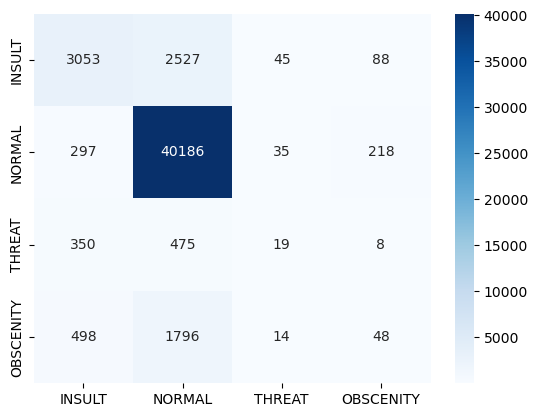

In [22]:
# на новых признаках
rf.fit(X_train_new, y_train)
y_pred_rf = rf.predict(X_test_new)

print_multiclass_metrics(y_test, y_pred_rf)

<h3> CatBoost

In [23]:

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


f1 macro score: 0.39814385764362425
f1 weighted score: 0.8472930523759319
LR accurcay: 0.8823126648810843
              precision    recall  f1-score   support

      INSULT       0.77      0.55      0.64      5713
      NORMAL       0.89      1.00      0.94     40736
      THREAT       0.17      0.00      0.00       852
   OBSCENITY       0.73      0.00      0.01      2356

    accuracy                           0.88     49657
   macro avg       0.64      0.39      0.40     49657
weighted avg       0.86      0.88      0.85     49657



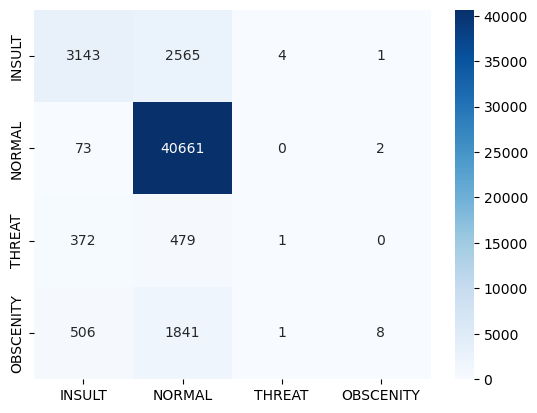

In [24]:
print_multiclass_metrics(y_test, y_pred)

<h2> Добавляем word2vec

#

<h4> Ма запустили парсер на основе библиотеки stanza и сохранили результат в файл comments_parsed.csv

<h5> В нем есть информация о lemma_POS слова и прочее. Это необходимо, чтобы векторизовать наши слова через word2vec

In [25]:
parsed_comments = pd.read_csv('../data/comments_parsed.csv')

In [26]:
w2v = api.load("word2vec-ruscorpora-300")

In [27]:
def preprocess(text):
    print(text)
    if isinstance(text, str):
        text = text.split('\t')
    else: 
        text = []
    return text

def vectorize(text, model):
    vectors = []
    # sentences = [i.split('\t') for i in text] 
    sentences = []
    for i in text:
        if isinstance(i, str):
            sentences.append(i.split('\t'))
        else:
            sentences.append([])
    for sent in tqdm(sentences):
        vec = []
        for word in sent:
            if word not in model:
                vec.append(np.zeros(model.vector_size))
            else:
                vec.append(model[word])
        if vec:
            vectors.append(np.mean(vec, axis=0))
        else:
            vectors.append(np.zeros(model.vector_size))
    return vectors


comment_vectors = vectorize(parsed_comments['lemma_pos'], w2v)
comment_vectors = np.stack(np.array(comment_vectors))

100%|██████████| 248281/248281 [00:03<00:00, 73181.65it/s]


In [28]:
df_multiclass_vectors = pd.DataFrame(comment_vectors, columns=[f"w2v_{i + 1}" for i in range(comment_vectors.shape[1])])
X = df_multiclass_vectors
y = df_multiclass['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

standard_scaler = preprocessing.StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

<h3> Logistic Regression word2vec-ruscorpora 

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


f1 macro score: 0.5693527974477147
f1 weighted score: 0.8337035177527584
LR accurcay: 0.8256841935678756
              precision    recall  f1-score   support

      INSULT       0.44      0.52      0.48      5713
      NORMAL       0.93      0.89      0.91     40736
      THREAT       0.31      0.52      0.39       852
   OBSCENITY       0.49      0.51      0.50      2356

    accuracy                           0.83     49657
   macro avg       0.54      0.61      0.57     49657
weighted avg       0.84      0.83      0.83     49657



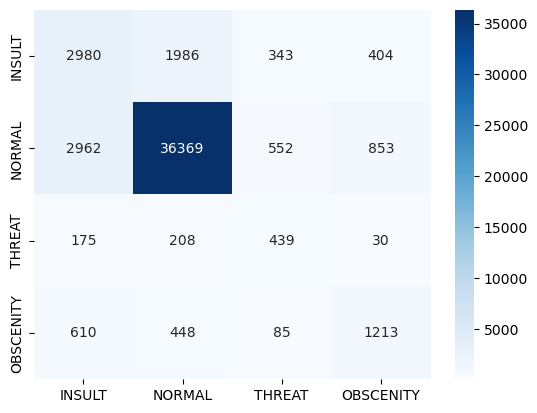

In [29]:
lr = linear_model.LogisticRegression(solver='liblinear', class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print_multiclass_metrics(y_test, y_pred)

<h3> KNN word2vec-ruscorpora 

f1 macro score: 0.5837325327976449
f1 weighted score: 0.858342622972666
LR accurcay: 0.8638459834464426
              precision    recall  f1-score   support

      INSULT       0.52      0.55      0.54      5713
      NORMAL       0.92      0.95      0.93     40736
      THREAT       0.59      0.28      0.38       852
   OBSCENITY       0.64      0.39      0.49      2356

    accuracy                           0.86     49657
   macro avg       0.67      0.54      0.58     49657
weighted avg       0.86      0.86      0.86     49657



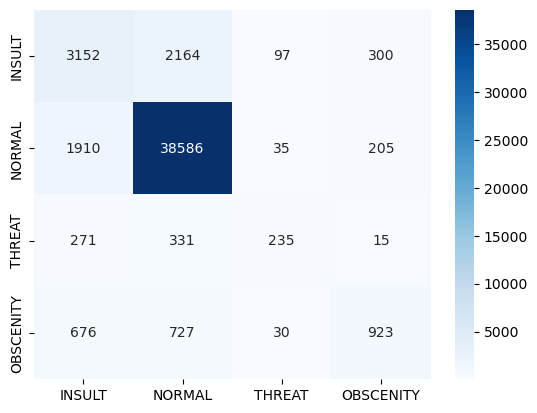

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print_multiclass_metrics(y_test, y_pred_knn)

<h3> Random Forest word2vec-ruscorpora 

f1 macro score: 0.5693527974477147
f1 weighted score: 0.8337035177527584
LR accurcay: 0.8256841935678756
              precision    recall  f1-score   support

      INSULT       0.44      0.52      0.48      5713
      NORMAL       0.93      0.89      0.91     40736
      THREAT       0.31      0.52      0.39       852
   OBSCENITY       0.49      0.51      0.50      2356

    accuracy                           0.83     49657
   macro avg       0.54      0.61      0.57     49657
weighted avg       0.84      0.83      0.83     49657



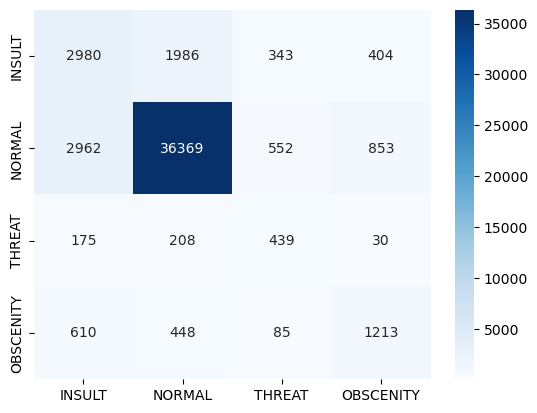

In [31]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print_multiclass_metrics(y_test, y_pred)

<h3> Catboost word2vec-ruscorpora 

In [32]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=0
)

model.fit(X_train, y_train)
y_pred_cb = model.predict(X_test)

f1 macro score: 0.6244776364827167
f1 weighted score: 0.8810267537801595
LR accurcay: 0.8931671264877057
              precision    recall  f1-score   support

      INSULT       0.71      0.53      0.61      5713
      NORMAL       0.92      0.98      0.95     40736
      THREAT       0.72      0.29      0.41       852
   OBSCENITY       0.74      0.42      0.53      2356

    accuracy                           0.89     49657
   macro avg       0.77      0.55      0.62     49657
weighted avg       0.88      0.89      0.88     49657



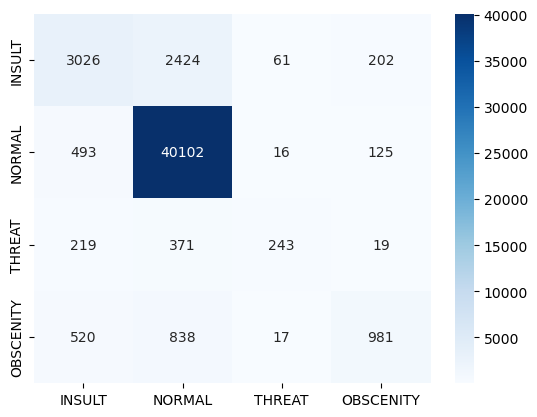

In [33]:
print_multiclass_metrics(y_test, y_pred_cb)

<h4> Итог:word2vec-ruscorpora-300 не дал заметного прироста к метрике, поскольку этот векторизатор обучен в основном на текстах из классической литературы и там встреачется мало токсичных сообщений или слов

#

<h2> word2vec araneum (RusVectores)

#

In [34]:
model_path = "../data/models/araneum_upos_skipgram_300_2_2018.vec"
w2v = KeyedVectors.load_word2vec_format(model_path, binary=False)

In [35]:
comment_vectors = vectorize(parsed_comments['lemma_pos'], w2v)
comment_vectors = np.stack(np.array(comment_vectors))

100%|██████████| 248281/248281 [00:03<00:00, 76381.28it/s]


In [36]:
df_multiclass_vectors = pd.DataFrame(comment_vectors, columns=[f"w2v_{i + 1}" for i in range(comment_vectors.shape[1])])
X = df_multiclass_vectors
y = df_multiclass['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

standard_scaler = preprocessing.StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

<h3> Linear Regression word2vec araneum

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


f1 macro score: 0.6313133177925662
f1 weighted score: 0.8743009098282895
LR accurcay: 0.875264313188473
              precision    recall  f1-score   support

      INSULT       0.66      0.56      0.61      5713
      NORMAL       0.94      0.95      0.94     40736
      THREAT       0.39      0.56      0.46       852
   OBSCENITY       0.51      0.53      0.52      2356

    accuracy                           0.88     49657
   macro avg       0.63      0.65      0.63     49657
weighted avg       0.87      0.88      0.87     49657



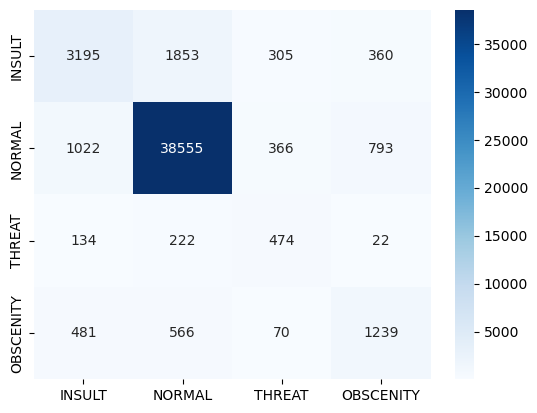

In [37]:
lr = linear_model.LogisticRegression(solver='liblinear', class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print_multiclass_metrics(y_test, y_pred)

<h3> KNN Regression word2vec araneum

f1 macro score: 0.6139004570955361
f1 weighted score: 0.8693412597813277
LR accurcay: 0.8723040054775761
              precision    recall  f1-score   support

      INSULT       0.55      0.63      0.59      5713
      NORMAL       0.93      0.94      0.94     40736
      THREAT       0.58      0.33      0.42       852
   OBSCENITY       0.67      0.41      0.51      2356

    accuracy                           0.87     49657
   macro avg       0.68      0.58      0.61     49657
weighted avg       0.87      0.87      0.87     49657



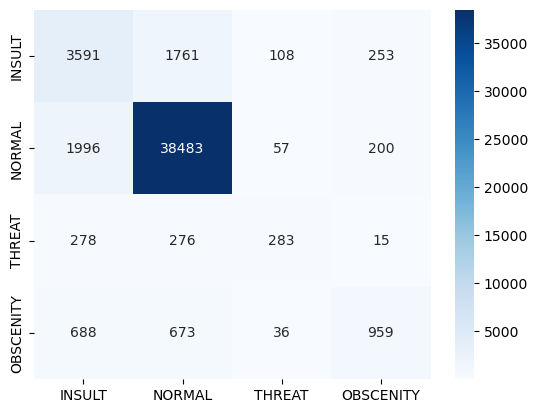

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print_multiclass_metrics(y_test, y_pred_knn)

<h3> Random Forest word2vec araneum

f1 macro score: 0.6313133177925662
f1 weighted score: 0.8743009098282895
LR accurcay: 0.875264313188473
              precision    recall  f1-score   support

      INSULT       0.66      0.56      0.61      5713
      NORMAL       0.94      0.95      0.94     40736
      THREAT       0.39      0.56      0.46       852
   OBSCENITY       0.51      0.53      0.52      2356

    accuracy                           0.88     49657
   macro avg       0.63      0.65      0.63     49657
weighted avg       0.87      0.88      0.87     49657



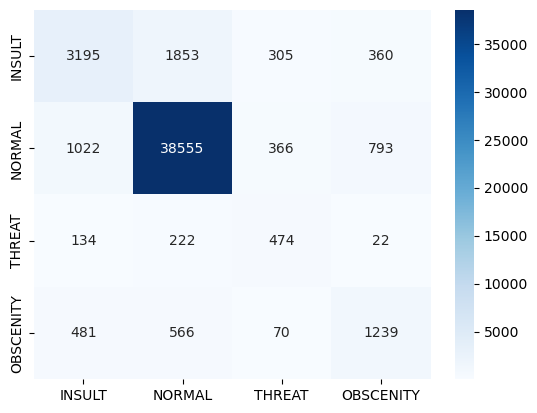

In [39]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print_multiclass_metrics(y_test, y_pred)

<h3> Catboost word2vec araneum

f1 macro score: 0.6674862135654946
f1 weighted score: 0.8954751724947242
LR accurcay: 0.9044042129004974
              precision    recall  f1-score   support

      INSULT       0.74      0.60      0.66      5713
      NORMAL       0.93      0.98      0.96     40736
      THREAT       0.71      0.38      0.50       852
   OBSCENITY       0.75      0.43      0.55      2356

    accuracy                           0.90     49657
   macro avg       0.78      0.60      0.67     49657
weighted avg       0.90      0.90      0.90     49657



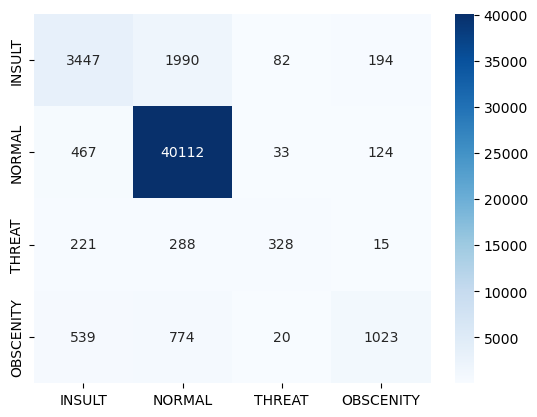

In [40]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=0
)

model.fit(X_train, y_train)
y_pred_cb = model.predict(X_test)
print_multiclass_metrics(y_test, y_pred_cb)

<h3> Добавим числовые признаки к векторам, чтобы сравнить результат

In [41]:

df_multiclass_vectors = pd.concat([df_multiclass, 
                                   pd.DataFrame(comment_vectors, columns=[f"w2v_{i + 1}" for i in range(comment_vectors.shape[1])])], 
                                   axis=1)
df_multiclass_vectors.drop(columns='text', inplace=True)
X = df_multiclass_vectors.drop(columns=['label'])
y = df_multiclass_vectors['label']

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=TEST_SIZE, 
                                                                    random_state=RANDOM_SEED, stratify=y)
le = preprocessing.LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

standard_scaler = preprocessing.StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

/Users/danil/miniforge3/envs/datascience/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


f1 macro score: 0.6790011873053625
f1 weighted score: 0.908278507664828
LR accurcay: 0.9084519805868256
              precision    recall  f1-score   support

      INSULT       0.76      0.72      0.74      5713
      NORMAL       0.96      0.96      0.96     40736
      THREAT       0.45      0.52      0.48       852
   OBSCENITY       0.54      0.53      0.53      2356

    accuracy                           0.91     49657
   macro avg       0.68      0.68      0.68     49657
weighted avg       0.91      0.91      0.91     49657



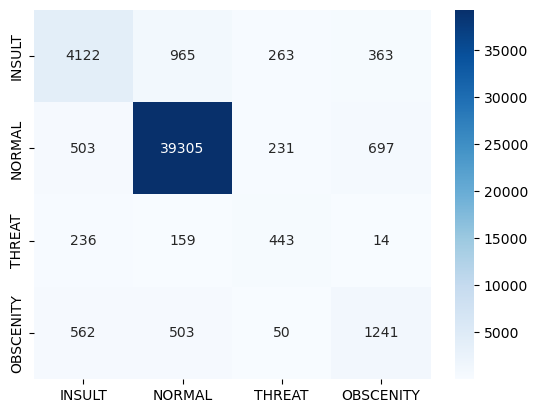

In [42]:
lr = linear_model.LogisticRegression(solver='liblinear', class_weight='balanced')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print_multiclass_metrics(y_test, y_pred)

Итог: лучший результат дала линейная регрессия, обученная числовых признаках и на векторах, полученных из word2vec araneum.